In [720]:
import numpy as np
import matplotlib.pyplot as plt

In [721]:
def linear(x, w, b):
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    return np.dot(x, w) + b

In [722]:
def activation(z):
    return np.maximum(0 ,z) #try 0.01 and 0.001 for leaky relu

In [723]:
def backprop(x, y, y_pred, z1, a1, w2):
    N = len(x)
    dL_dy_pred = 2.0 * (y_pred - y) / N  # Average gradient

    dw2 = np.dot(a1.T, dL_dy_pred)        # Do NOT divide by N again here
    db2 = np.sum(dL_dy_pred, axis=0, keepdims=True)

    dL_da1 = np.dot(dL_dy_pred, w2.T)
    dL_dz1 = dL_da1 * (z1 > 0)

    dw1 = np.dot(x.T, dL_dz1)             # Do NOT divide by N again here
    db1 = np.sum(dL_dz1, axis=0, keepdims=True)
    
    return dw1, db1, dw2, db2

In [724]:
def init():
    w1 = np.random.randn(1, 50) * np.sqrt(2.0 / 1)
    b1 = np.zeros((1, 50))

    w2 = np.random.randn(50, 1) * np.sqrt(2.0 / 50)
    b2 = np.zeros((1, 1))
    
    return w1, b1, w2, b2

In [725]:
def model_train_k1(x, y):
    learning_rate = 0.001
    x = np.array(x, dtype=np.float64).reshape(-1, 1)
    y = np.array(y, dtype=np.float64).reshape(-1, 1)
    w1, b1, w2, b2 = init()
    if y.ndim == 1: y = y.reshape(-1, 1)
    for i in range(10000):
        # Forward Pass
        z1 = linear(x, w1, b1)
        a1 = np.maximum(0, z1)
        y_pred = linear(a1, w2, b2)
        loss = np.mean((y - y_pred) ** 2)
        # Backpropagation
        dw1, db1, dw2, db2 = backprop(x, y, y_pred, z1, a1, w2)
        # Updates
        w1 -= learning_rate * dw1
        b1 -= learning_rate * db1
        w2 -= learning_rate * dw2
        b2 -= learning_rate * db2
    return w1, b1, w2, b2

In [ ]:
step = 0.001
iter = 20001
start = -10
end = 1
x_data = np.array([])
y_data = np.array([])
for i in range(iter):
    x_data = np.append(x_data, [start])
    y_data = np.append(y_data, [np.square(start)])
    start = start + step

x_data = x_data.reshape(-1, 1)
y_data = y_data.reshape(-1, 1)
trained_w1, trained_b1, trained_w2, trained_b2 = model_train_k1(x_data, y_data)

KeyboardInterrupt: 

In [727]:
def predict(x_new, w1, b1, w2, b2):
    x_new = np.array(x_new, dtype=np.float64).reshape(-1, 1)
    a1 = activation(linear(x_new, w1, b1))
    y_pred = linear(a1, w2, b2)
    return y_pred

In [728]:
x_test = np.array([-2.0, -1.0, 3, 0.5, 0.02, 0.4])
y_test = np.array([4, 1, 9, 0.25, 0.0004, 0.16])

In [729]:
x_data
y_data

array([[100.      ],
       [ 99.980001],
       [ 99.960004],
       ...,
       [ 99.960004],
       [ 99.980001],
       [100.      ]], shape=(20001, 1))

In [730]:
y_test_pred

array([[-1801.88985838,    47.53656449],
       [  173.99958154,   273.71361434],
       [ -755.95938327, -1360.9934948 ],
       ...,
       [ 1337.32151191,   252.686822  ],
       [-1608.20467501, -1462.04440047],
       [-1799.01884008,  1102.27454173]], shape=(1000000, 2))

Number of points retained: 1876
Total points tested: 100000


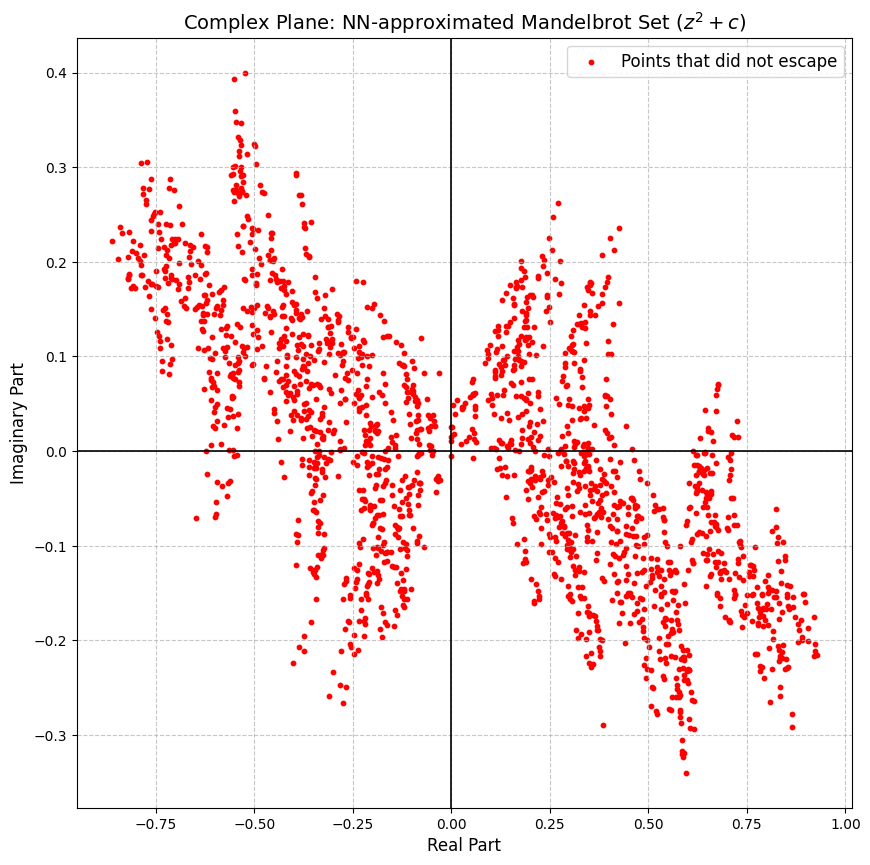

In [732]:
import numpy as np
import matplotlib.pyplot as plt

real_test = np.random.uniform(-1, 1, 100000)
imag_test = np.random.uniform(-1, 1, 100000)

n_iters = 25
bailout = 2.0

# c is now a single fixed constant for the whole set
c_real, c_imag = -0.8, 0.156   # classic dendrite-like Julia set

# z starts AT the sampled point instead of at 0
z_real = real_test.copy()
z_imag = imag_test.copy()
escaped = np.zeros(len(real_test), dtype=bool)

for i in range(n_iters):
    zr_sq = predict(z_real, trained_w1, trained_b1, trained_w2, trained_b2).flatten()
    zi_sq = predict(z_imag, trained_w1, trained_b1, trained_w2, trained_b2).flatten()
    #zr_sq = z_real **2
    #zi_sq = z_imag **2

    new_real = zr_sq - zi_sq + c_real
    new_imag = 2 * z_real * z_imag + c_imag

    active = ~escaped
    z_real[active] = new_real[active]
    z_imag[active] = new_imag[active]

    mag = np.sqrt(z_real**2 + z_imag**2)
    newly_escaped = (~escaped) & (mag > bailout)
    escaped |= newly_escaped
    z_real[escaped] = bailout * 2
    z_imag[escaped] = bailout * 2

mask = ~escaped
x_filtered = np.column_stack((real_test, imag_test))[mask]

# Plotting on the Complex Plane
plt.figure(figsize=(10, 10))

plt.scatter(x_filtered[:, 0], x_filtered[:, 1], color='red', marker='o',
            label='Points that did not escape', s=10)

plt.xlabel('Real Part', fontsize=12)
plt.ylabel('Imaginary Part', fontsize=12)
plt.title('Complex Plane: NN-approximated Mandelbrot Set ($z^2 + c$)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

print("Number of points retained:", len(x_filtered))
print("Total points tested:", len(real_test))

# Make axes pass through the origin for better visualization
plt.axhline(0, color='black', linewidth=1.2)
plt.axvline(0, color='black', linewidth=1.2)

plt.show()